#### Download Required Libraries

In [4]:
!pip install requests
!pip install beautifulsoup4
!pip install lxml
!pip install pandas
!pip install matplotlib
!pip install seaborn

#### Import Libraries

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

#### Define Website URL

In [8]:
url = "https://www.screener.in/market/"
url

'https://www.screener.in/market/'

In [9]:
headers = {
    "User-Agent":"Mozilla/5.0"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [10]:
soup = BeautifulSoup(response.text, "lxml")

In [11]:
links=soup.find_all("a")

In [12]:
base_url = "https://www.screener.in"

sector_urls = []

for link in links:

    href = link.get("href")

    if href and href.startswith("/market/"):

        sector_urls.append(base_url + href)

sector_urls

['https://www.screener.in/market/IN02/IN0201/IN020101/IN020101002/',
 'https://www.screener.in/market/IN07/IN0702/IN070205/IN070205016/',
 'https://www.screener.in/market/IN02/IN0204/IN020401/IN020401001/',
 'https://www.screener.in/market/IN07/IN0702/IN070201/IN070201001/',
 'https://www.screener.in/market/IN09/IN0901/IN090102/IN090102001/',
 'https://www.screener.in/market/IN09/IN0901/IN090103/IN090103001/',
 'https://www.screener.in/market/IN01/IN0103/IN010302/IN010302001/',
 'https://www.screener.in/market/IN07/IN0702/IN070205/IN070205014/',
 'https://www.screener.in/market/IN02/IN0206/IN020601/IN020601003/',
 'https://www.screener.in/market/IN04/IN0401/IN040104/IN040104001/',
 'https://www.screener.in/market/IN05/IN0501/IN050103/IN050103001/',
 'https://www.screener.in/market/IN02/IN0201/IN020102/IN020102001/',
 'https://www.screener.in/market/IN02/IN0201/IN020101/IN020101004/',
 'https://www.screener.in/market/IN06/IN0601/IN060101/IN060101002/',
 'https://www.screener.in/market/I

In [13]:
sector_urls = list(set(sector_urls))

print(len(sector_urls))

188


In [14]:
url = sector_urls[0]

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "lxml")

In [15]:
table = soup.find("table")

table

<table class="data-table text-nowrap striped mark-visited no-scroll-right highlight-on-hover">
<tbody>
<tr>
<th class="text" scope="colgroup">
<a aria-label="Default Sort" class="" href="?order=asc">S.No.</a>
</th>
<th class="text" scope="colgroup">
<a aria-label="Sort on Name" class="" href="?sort=name&amp;order=desc">Name</a>
</th>
<th data-tooltip="Current Price" scope="colgroup">
<a aria-label="Sort on Current Price" class="" href="?sort=current+price&amp;order=desc">
                    CMP
                    <span style="color: hsl(0, 0%, 45%)">Rs.</span>
</a>
</th>
<th data-tooltip="Price to Earning" scope="colgroup">
<a aria-label="Sort on Price to Earning" class="" href="?sort=price+to+earning&amp;order=desc">
                    P/E
                    <span style="color: hsl(0, 0%, 45%)"></span>
</a>
</th>
<th data-tooltip="Market Capitalization" scope="colgroup">
<a aria-label="Sort on Market Capitalization" class="desc" href="?sort=market+capitalization&amp;order=desc">
 

In [16]:
header_row = table.find("tr")

table_headers = [th.get_text(" ", strip=True) for th in header_row.find_all("th")]

print(table_headers)

['S.No.', 'Name', 'CMP Rs.', 'P/E', 'Mar Cap Rs.Cr.', 'Div Yld %', 'NP Qtr Rs.Cr.', 'Qtr Profit Var %', 'Sales Qtr Rs.Cr.', 'Qtr Sales Var %', 'ROCE %']


In [17]:
rows = table.find_all("tr")

In [18]:
sector_data = []

for row in rows[1:]:

    cols = row.find_all("td")

    cols = [col.text.strip() for col in cols]

    if cols:

        sector_data.append(cols)

In [19]:
df = pd.DataFrame(sector_data, columns=table_headers)
df

,S.No.,Name,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %
0,1.,Cera Sanitary.,5670.95,35.45,7314.14,1.29,45.31,-2.62,485.98,19.46,19.25
1,2.,Hindware Home In,199.90,,1672.07,0.00,4.37,-78.72,625.25,17.71,7.07
2,3.,Ganga Bath Fitt.,21.95,38.08,48.75,0.00,0.89,-17.59,18.27,17.27,5.62


In [20]:
sector_name = soup.find("h1").text.strip()

df["Sector"] = sector_name

In [21]:
# Take only first 15 sector URLs
sector_urls = sector_urls[:180]

print(f"Total sectors to scrape: {len(sector_urls)}")

Total sectors to scrape: 180


In [22]:
master_df = pd.DataFrame()

request_headers = {
    "User-Agent": "Mozilla/5.0"
}

for url in sector_urls:

    response = requests.get(url, headers=request_headers)

    soup = BeautifulSoup(response.text, "lxml")

    table = soup.find("table")

    if table is None:
        print(f"No table found: {url}")
        continue

    header_row = table.find("tr")

    table_headers = [
        th.get_text(" ", strip=True)
        for th in header_row.find_all("th")
    ]

    rows = table.find_all("tr")

    data = []

    for row in rows[1:]:

        cols = row.find_all("td")

        cols = [col.get_text(" ", strip=True) for col in cols]

        if len(cols) == len(table_headers):
            data.append(cols)

    df = pd.DataFrame(data, columns=table_headers)

    sector_name = soup.find("h1").get_text(strip=True)

    df["Sector"] = sector_name

    master_df = pd.concat([master_df, df], ignore_index=True)

    print(f"Completed: {sector_name}")

    time.sleep(1)

Completed: Sanitary Ware Companies
Completed: Glass - Industrial Companies
Completed: Leather And Leather Products Companies
Completed: Sponge Iron Companies
Completed: Electronic Media Companies
Completed: Animal Feed Companies
Completed: Business Process Outsourcing (BPO)/ Knowledge Process Outsourcing (KPO) Companies
Completed: Rubber Companies
Completed: 2/3 Wheelers Companies
Completed: Paints Companies
Completed: Pesticides & Agrochemicals Companies
Completed: TV Broadcasting & Software Production Companies
Completed: Diversified Commercial Services Companies
Completed: Integrated Power Utilities Companies
Completed: Aluminium, Copper & Zinc Products Companies
Completed: Jute & Jute Products Companies
Completed: Meat Products including Poultry Companies
Completed: Carbon Black Companies
Completed: Road Transport Companies
Completed: Breweries & Distilleries Companies
Completed: Printing & Publication Companies
Completed: Financial Products Distributor Companies
Completed: Deposit

#### Save the dataset 

In [24]:
master_df.to_csv("Cleaned_Sector_Data.csv", index=False)

## Data Understanding

In [26]:
import pandas as pd

In [27]:
master_df=pd.read_csv('Cleaned_Sector_Data.csv')

In [28]:
master_df.head()

,S.No.,Name,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %,Sector
0,1.0,Cera Sanitary.,5670.95,35.45,7314.14,1.29,45.31,-2.62,485.98,19.46,19.25,Sanitary Ware Companies
1,2.0,Hindware Home In,199.90,NaN,1672.07,0.00,4.37,-78.72,625.25,17.71,7.07,Sanitary Ware Companies
2,3.0,Ganga Bath Fitt.,21.95,38.08,48.75,0.00,0.89,-17.59,18.27,17.27,5.62,Sanitary Ware Companies
3,1.0,Borosil Renew.,550.00,20.14,8095.08,0.00,87.71,156.91,405.69,22.10,26.62,Glass - Industrial Companies
4,2.0,Borosil Scienti.,128.60,25.73,1143.91,0.00,4.35,93.97,106.75,11.22,12.08,Glass - Industrial Companies


In [29]:
master_df.shape

(2430, 12)

In [30]:
master_df.tail()

,S.No.,Name,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %,Sector
2425,3.0,Gujarat Energy,265.90,12.78,24947.61,2.15,1007.40,69.80,9544.98,63.12,18.49,LPG/CNG/PNG/LNG Supplier Companies
2426,4.0,Indraprastha Gas,153.05,15.74,21427.02,2.11,237.92,-43.97,4586.73,17.19,17.90,LPG/CNG/PNG/LNG Supplier Companies
2427,5.0,Mahanagar Gas,1128.80,15.46,11150.09,2.62,193.70,-39.39,2371.71,13.95,17.14,LPG/CNG/PNG/LNG Supplier Companies
2428,6.0,Confidence Petro,73.00,18.04,2425.32,0.14,62.55,207.04,2408.53,116.60,9.23,LPG/CNG/PNG/LNG Supplier Companies
2429,7.0,IRM Energy,287.00,16.07,1178.43,0.52,33.81,142.89,325.85,24.13,8.63,LPG/CNG/PNG/LNG Supplier Companies


In [31]:
master_df["Sector"].unique()

array(['Sanitary Ware Companies', 'Glass - Industrial Companies',
       'Leather And Leather Products Companies', 'Sponge Iron Companies',
       'Electronic Media Companies', 'Animal Feed Companies',
       'Business Process Outsourcing (BPO)/ Knowledge Process Outsourcing (KPO) Companies',
       'Rubber Companies', '2/3 Wheelers Companies', 'Paints Companies',
       'Pesticides & Agrochemicals Companies',
       'TV Broadcasting & Software Production Companies',
       'Diversified Commercial Services Companies',
       'Integrated Power Utilities Companies',
       'Aluminium, Copper & Zinc Products Companies',
       'Jute & Jute Products Companies',
       'Meat Products including Poultry Companies',
       'Carbon Black Companies', 'Road Transport Companies',
       'Breweries & Distilleries Companies',
       'Printing & Publication Companies',
       'Financial Products Distributor Companies',
       'Depositories, Clearing Houses and Other Intermediaries Companies',
       

In [32]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430 entries, 0 to 2429
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S.No.             2430 non-null   float64
 1   Name              2430 non-null   object 
 2   CMP Rs.           2430 non-null   float64
 3   P/E               2055 non-null   float64
 4   Mar Cap Rs.Cr.    2430 non-null   float64
 5   Div Yld %         2430 non-null   float64
 6   NP Qtr Rs.Cr.     2414 non-null   float64
 7   Qtr Profit Var %  2364 non-null   float64
 8   Sales Qtr Rs.Cr.  2414 non-null   float64
 9   Qtr Sales Var %   2291 non-null   float64
 10  ROCE %            2369 non-null   float64
 11  Sector            2430 non-null   object 
dtypes: float64(10), object(2)
memory usage: 227.9+ KB


In [33]:
master_df['Name'].nunique()

2430

In [34]:
master_df.describe()

,S.No.,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %
count,2430.000000,2.430000e+03,2055.000000,2.430000e+03,2430.000000,2414.000000,2364.000000,2414.000000,2291.000000,2369.000000
mean,10.146914,1.743196e+03,75.091440,1.872271e+04,0.538099,209.863571,182.033748,2351.143662,67.354221,10.302111
std,6.995280,3.049687e+04,682.376264,7.653914e+04,1.297205,1230.203655,3165.306882,14010.096679,753.711045,140.313434
min,1.000000,1.900000e-01,0.510000,1.480000e+00,0.000000,-12264.670000,-29250.000000,-1.930000,-100.000000,-6733.330000
25%,4.000000,6.294750e+01,14.395000,1.881450e+02,0.000000,1.122500,-15.687500,39.997500,3.765000,5.710000
50%,9.000000,1.969500e+02,24.560000,1.196055e+03,0.000000,10.370000,23.520000,190.800000,17.270000,11.920000
75%,15.000000,5.877500e+02,47.605000,8.040715e+03,0.577500,66.080000,86.082500,856.225000,35.275000,19.640000
max,25.000000,1.100000e+06,29046.410000,1.769379e+06,31.000000,25120.890000,107300.000000,309468.000000,28133.330000,162.470000


In [35]:
master_df.isnull().sum()

S.No.                 0
Name                  0
CMP Rs.               0
P/E                 375
Mar Cap Rs.Cr.        0
Div Yld %             0
NP Qtr Rs.Cr.        16
Qtr Profit Var %     66
Sales Qtr Rs.Cr.     16
Qtr Sales Var %     139
ROCE %               61
Sector                0
dtype: int64

In [36]:
master_df.duplicated().sum()

0

In [37]:
master_df["Sector"].value_counts()

Sector
Residential, Commercial Projects Companies        25
Packaged Foods Companies                          25
Paper & Paper Products Companies                  25
Investment Company Companies                      25
Non Banking Financial Company (NBFC) Companies    25
                                                  ..
Industrial Machinery Companies                     1
Glass - Consumer Companies                         1
Trading - Gas Companies                            1
Insurance Distributors Companies                   1
Pig Iron Companies                                 1
Name: count, Length: 180, dtype: int64

In [38]:
print(master_df["Name"].nunique())

2430


In [39]:
print(master_df["Sector"].nunique())

180


In [40]:
master_df.dtypes

S.No.               float64
Name                 object
CMP Rs.             float64
P/E                 float64
Mar Cap Rs.Cr.      float64
Div Yld %           float64
NP Qtr Rs.Cr.       float64
Qtr Profit Var %    float64
Sales Qtr Rs.Cr.    float64
Qtr Sales Var %     float64
ROCE %              float64
Sector               object
dtype: object

## Data Cleaning

In [42]:
master_df["Mar Cap Rs.Cr."]

0        7314.14
1        1672.07
2          48.75
3        8095.08
4        1143.91
          ...   
2425    24947.61
2426    21427.02
2427    11150.09
2428     2425.32
2429     1178.43
Name: Mar Cap Rs.Cr., Length: 2430, dtype: float64

In [43]:
numeric_cols = [
    "CMP Rs.",
    "P/E",
    "Mar Cap Rs.Cr.",
    "Div Yld %",
    "NP Qtr Rs.Cr.",
    "Qtr Profit Var %",
    "Sales Qtr Rs.Cr.",
    "Qtr Sales Var %",
    "ROCE %"
]

for col in numeric_cols:
    master_df[col] = pd.to_numeric(master_df[col], errors="coerce")

In [44]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430 entries, 0 to 2429
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   S.No.             2430 non-null   float64
 1   Name              2430 non-null   object 
 2   CMP Rs.           2430 non-null   float64
 3   P/E               2055 non-null   float64
 4   Mar Cap Rs.Cr.    2430 non-null   float64
 5   Div Yld %         2430 non-null   float64
 6   NP Qtr Rs.Cr.     2414 non-null   float64
 7   Qtr Profit Var %  2364 non-null   float64
 8   Sales Qtr Rs.Cr.  2414 non-null   float64
 9   Qtr Sales Var %   2291 non-null   float64
 10  ROCE %            2369 non-null   float64
 11  Sector            2430 non-null   object 
dtypes: float64(10), object(2)
memory usage: 227.9+ KB


In [45]:
master_df.isnull().sum()

S.No.                 0
Name                  0
CMP Rs.               0
P/E                 375
Mar Cap Rs.Cr.        0
Div Yld %             0
NP Qtr Rs.Cr.        16
Qtr Profit Var %     66
Sales Qtr Rs.Cr.     16
Qtr Sales Var %     139
ROCE %               61
Sector                0
dtype: int64

#### Filling null values with the median of the particular sector

In [47]:
numeric_cols = [
    "P/E",
    "NP Qtr Rs.Cr.",
    "Qtr Profit Var %",
    "Sales Qtr Rs.Cr.",
    "Qtr Sales Var %",
    "ROCE %"
]

for col in numeric_cols:
    master_df[col] = master_df.groupby("Sector")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [48]:
master_df.isnull().sum()

S.No.               0
Name                0
CMP Rs.             0
P/E                 0
Mar Cap Rs.Cr.      0
Div Yld %           0
NP Qtr Rs.Cr.       0
Qtr Profit Var %    0
Sales Qtr Rs.Cr.    0
Qtr Sales Var %     0
ROCE %              0
Sector              0
dtype: int64

# Descriptive Stats

In [135]:
numeric_cols = [
    "CMP Rs.",
    "P/E",
    "Mar Cap Rs.Cr.",
    "Div Yld %",
    "NP Qtr Rs.Cr.",
    "Qtr Profit Var %",
    "Sales Qtr Rs.Cr.",
    "Qtr Sales Var %",
    "ROCE %"
]

master_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CMP Rs.,2430.0,1743.196156,30496.866166,0.19,62.9475,196.950,587.7500,1100000.00
P/E,2430.0,67.599436,627.769626,0.51,14.8650,24.315,43.3000,29046.41
Mar Cap Rs.Cr.,2430.0,18722.713811,76539.142808,1.48,188.1450,1196.055,8040.7150,1769378.97
Div Yld %,2430.0,0.538099,1.297205,0.00,0.0000,0.000,0.5775,31.00
NP Qtr Rs.Cr.,2430.0,208.646393,1226.241115,-12264.67,1.1225,10.350,65.8325,25120.89
Qtr Profit Var %,2430.0,177.802718,3122.113708,-29250.00,-14.4500,23.600,83.1750,107300.00
Sales Qtr Rs.Cr.,2430.0,2338.204416,13964.859311,-1.93,39.9975,190.735,851.5025,309468.00
Qtr Sales Var %,2430.0,64.541208,731.925331,-100.00,4.1900,17.080,34.5775,28133.33
ROCE %,2430.0,10.296387,138.542946,-6733.33,5.6825,11.840,19.4650,162.47


In [137]:
stats_summary = master_df[numeric_cols].agg(
    ["mean", "median", "std", "min", "max"]
).T

stats_summary

,mean,median,std,min,max
CMP Rs.,1743.196156,196.950,30496.866166,0.19,1100000.00
P/E,67.599436,24.315,627.769626,0.51,29046.41
Mar Cap Rs.Cr.,18722.713811,1196.055,76539.142808,1.48,1769378.97
Div Yld %,0.538099,0.000,1.297205,0.00,31.00
NP Qtr Rs.Cr.,208.646393,10.350,1226.241115,-12264.67,25120.89
Qtr Profit Var %,177.802718,23.600,3122.113708,-29250.00,107300.00
Sales Qtr Rs.Cr.,2338.204416,190.735,13964.859311,-1.93,309468.00
Qtr Sales Var %,64.541208,17.080,731.925331,-100.00,28133.33
ROCE %,10.296387,11.840,138.542946,-6733.33,162.47


In [139]:
#Sector-wise Descriptive Statistics 

sector_stats = master_df.groupby("Sector")[[
    "P/E",
    "Mar Cap Rs.Cr.",
    "Div Yld %",
    "Qtr Profit Var %",
    "Qtr Sales Var %",
    "ROCE %"
]].agg(["mean", "median", "std"])

sector_stats.head()

P/E                      \
                                              mean  median         std   
Sector                                                                   
2/3 Wheelers Companies                   39.506154  23.930   46.708397   
Abrasives & Bearings Companies          106.045000  68.335  123.108897   
Advertising & Media Agencies Companies   50.708750  12.650  181.208684   
Aerospace & Defense Companies           128.915600  82.250  197.506882   
Airline Companies                        18.760000  18.760    1.583919   

                                       Mar Cap Rs.Cr.            \
                                                 mean    median   
Sector                                                            
2/3 Wheelers Companies                   72152.747692  1759.890   
Abrasives & Bearings Companies           10208.127778  8043.570   
Advertising & Media Agencies Companies     190.799167    54.375   
Aerospace & Defense Companies            35534.431600  7619.970   
Airline Companies                        40851.940000  1305.440   

                                                      Div Yld %         \
                                                  std      mean median   
Sector                                                                   
2/3 Wheelers Companies                  109138.293748  0.596923   0.00   
Abrasives & Bearings Companies           10361.817145  0.631111   0.37   
Advertising & Media Agencies Companies     319.690310  0.435417   0.00   
Aerospace & Defense Companies            85566.419439  0.158800   0.09   
Airline Companies                        89023.932609  0.350000   0.00   

                                                 Qtr Profit Var %         \
                                             std             mean median   
Sector                                                                     
2/3 Wheelers Companies                  0.962898         2.761538  21.35   
Abrasives & Bearings Companies          0.769000         3.852222  15.44   
Advertising & Media Agencies Companies  1.023999       659.135417  20.91   
Aerospace & Defense Companies           0.218276       -80.870400  14.88   
Airline Companies                       0.681396      -227.944000 -25.66   

                                                    Qtr Sales Var %         \
                                                std            mean median   
Sector                                                                       
2/3 Wheelers Companies                    67.798896       23.526923  31.55   
Abrasives & Bearings Companies            43.876254       13.820000  14.87   
Advertising & Media Agencies Companies  2694.437923      106.317917  15.82   
Aerospace & Defense Companies            368.385064      329.432800  35.66   
Airline Companies                        494.296596       27.850000  19.94   

                                                        ROCE %         \
                                                std       mean median   
Sector                                                                  
2/3 Wheelers Companies                    48.951329  13.343846  13.28   
Abrasives & Bearings Companies            13.410242  11.045556  11.38   
Advertising & Media Agencies Companies   430.449895  19.516667  17.23   
Aerospace & Defense Companies           1410.155250  18.401600  14.47   
Airline Companies                         25.144981  14.436000   9.10   

                                                   
                                              std  
Sector                                             
2/3 Wheelers Companies                  18.086494  
Abrasives & Bearings Companies          13.292848  
Advertising & Media Agencies Companies  20.761945  
Aerospace & Defense Companies           14.889076  
Airline Companies                       14.850762

In [141]:
# Correlation Analysis

corr = master_df[numeric_cols].corr()

corr

,CMP Rs.,P/E,Mar Cap Rs.Cr.,Div Yld %,NP Qtr Rs.Cr.,Qtr Profit Var %,Sales Qtr Rs.Cr.,Qtr Sales Var %,ROCE %
CMP Rs.,1.000000,0.018028,0.006394,0.080241,0.000695,0.282607,-0.000722,-0.002669,0.000942
P/E,0.018028,1.000000,-0.007059,-0.023322,-0.011799,0.017283,-0.009091,0.018728,-0.002700
Mar Cap Rs.Cr.,0.006394,-0.007059,1.000000,0.121701,0.838749,-0.009249,0.637108,-0.011802,0.015646
Div Yld %,0.080241,-0.023322,0.121701,1.000000,0.156786,0.030038,0.180910,-0.021074,0.018580
NP Qtr Rs.Cr.,0.000695,-0.011799,0.838749,0.156786,1.000000,-0.004242,0.566647,-0.009794,0.010728
Qtr Profit Var %,0.282607,0.017283,-0.009249,0.030038,-0.004242,1.000000,-0.005964,0.017164,0.003890
Sales Qtr Rs.Cr.,-0.000722,-0.009091,0.637108,0.180910,0.566647,-0.005964,1.000000,-0.008394,0.007254
Qtr Sales Var %,-0.002669,0.018728,-0.011802,-0.021074,-0.009794,0.017164,-0.008394,1.000000,0.016858
ROCE %,0.000942,-0.002700,0.015646,0.018580,0.010728,0.003890,0.007254,0.016858,1.000000


## Exploratory Data Analysis

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/h1/z0v69k1s7sx1hp22mh7yjs000000gn/T/ipykernel_32600/1050724235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


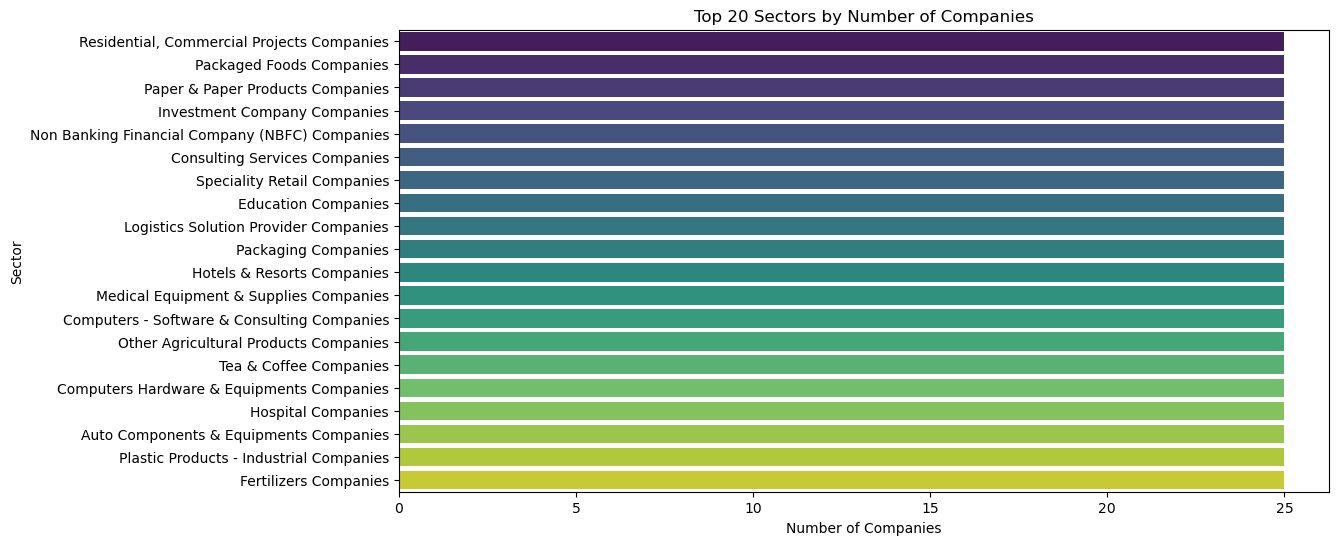

In [51]:
#1. Companies per Sector

sector_count = master_df["Sector"].value_counts().nlargest(20)

plt.figure(figsize=(12,6))
sns.barplot(
    x=sector_count.values,
    y=sector_count.index,
    palette="viridis"
)

plt.title("Top 20 Sectors by Number of Companies")
plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.show()

/var/folders/h1/z0v69k1s7sx1hp22mh7yjs000000gn/T/ipykernel_32600/3027374037.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


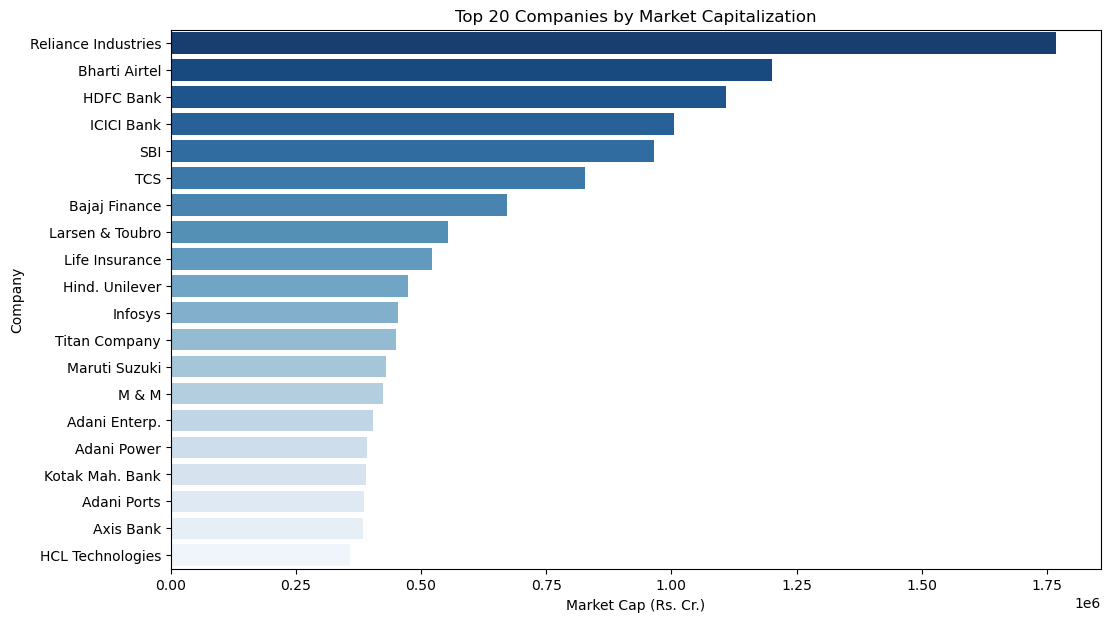

In [52]:
#2. Top 20 Companies by Market Capitalization

#Which companies dominate the market?

top_market = master_df.nlargest(20, "Mar Cap Rs.Cr.")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_market,
    x="Mar Cap Rs.Cr.",
    y="Name",
    palette="Blues_r"
)

plt.title("Top 20 Companies by Market Capitalization")
plt.xlabel("Market Cap (Rs. Cr.)")
plt.ylabel("Company")
plt.show()

/var/folders/h1/z0v69k1s7sx1hp22mh7yjs000000gn/T/ipykernel_32600/602810016.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


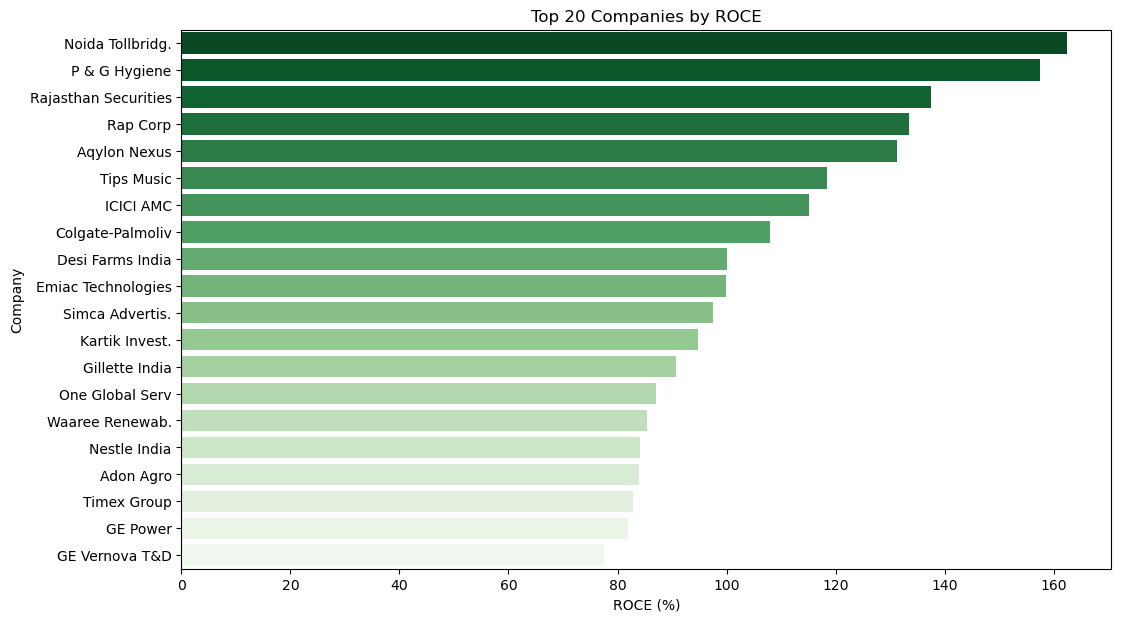

In [53]:
#3. Top 20 Companies by ROCE

#Which companies utilize capital most efficiently?

top_roce = master_df.nlargest(20, "ROCE %")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_roce,
    x="ROCE %",
    y="Name",
    palette="Greens_r"
)

plt.title("Top 20 Companies by ROCE")
plt.xlabel("ROCE (%)")
plt.ylabel("Company")
plt.show()

/var/folders/h1/z0v69k1s7sx1hp22mh7yjs000000gn/T/ipykernel_32600/4069162577.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


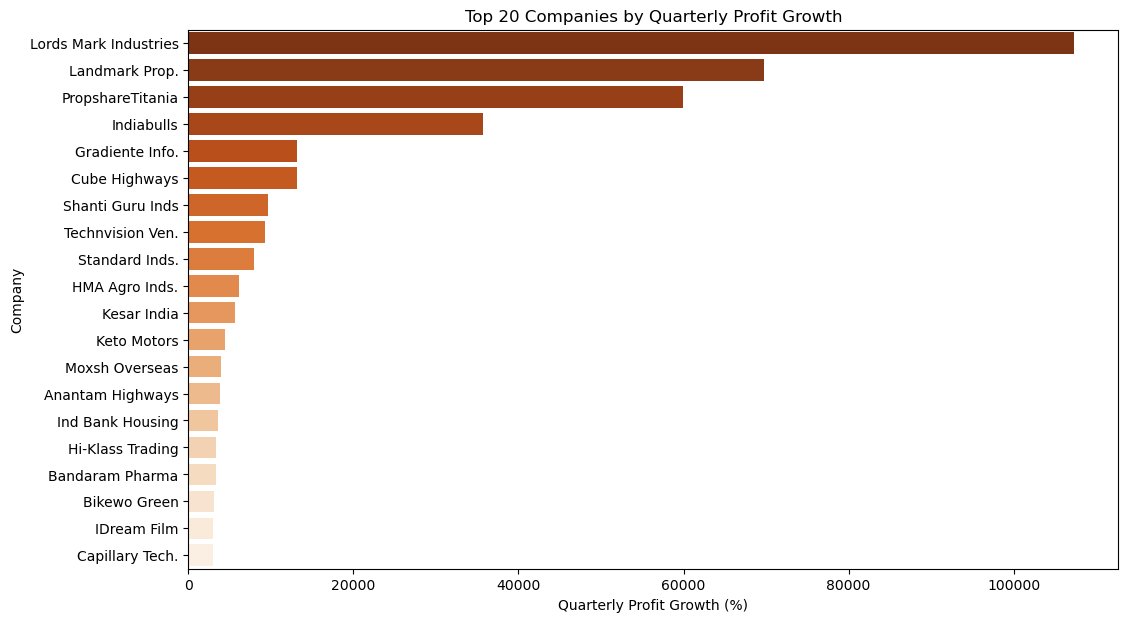

In [54]:
#4. Top 20 Companies by Quarterly Profit Growth

top_profit = master_df.nlargest(20, "Qtr Profit Var %")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_profit,
    x="Qtr Profit Var %",
    y="Name",
    palette="Oranges_r"
)

plt.title("Top 20 Companies by Quarterly Profit Growth")
plt.xlabel("Quarterly Profit Growth (%)")
plt.ylabel("Company")
plt.show()

/var/folders/h1/z0v69k1s7sx1hp22mh7yjs000000gn/T/ipykernel_32600/3211279193.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


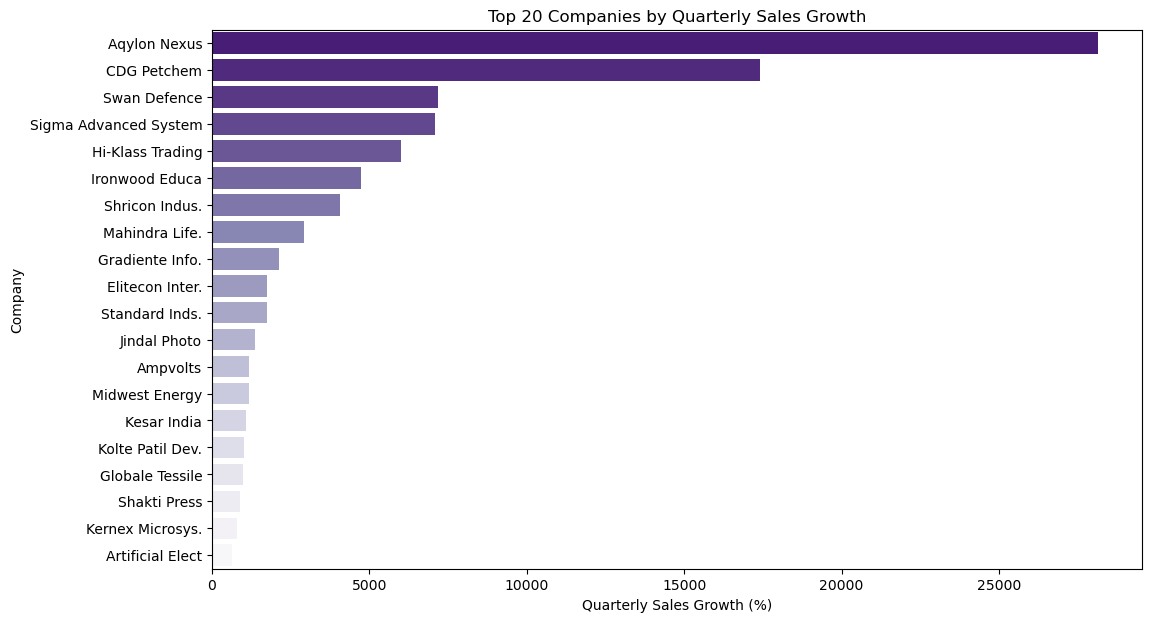

In [55]:
#5. Top 20 Companies by Quarterly Sales Growth

top_sales = master_df.nlargest(20, "Qtr Sales Var %")

plt.figure(figsize=(12,7))
sns.barplot(
    data=top_sales,
    x="Qtr Sales Var %",
    y="Name",
    palette="Purples_r"
)

plt.title("Top 20 Companies by Quarterly Sales Growth")
plt.xlabel("Quarterly Sales Growth (%)")
plt.ylabel("Company")
plt.show()

In [56]:
import warnings
warnings.filterwarnings('ignore')

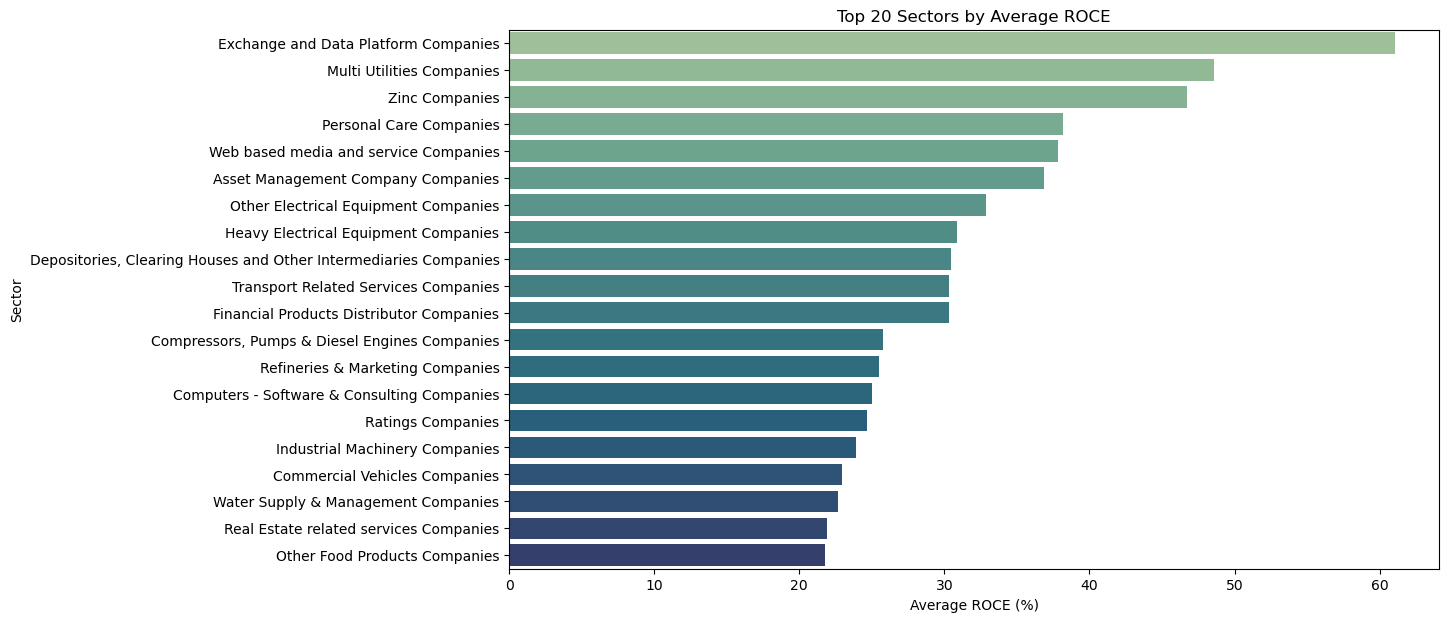

In [57]:
#6. Average ROCE by Sector

sector_roce = (
    master_df.groupby("Sector")["ROCE %"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))
sns.barplot(
    x=sector_roce.values,
    y=sector_roce.index,
    palette="crest"
)

plt.title("Top 20 Sectors by Average ROCE")
plt.xlabel("Average ROCE (%)")
plt.ylabel("Sector")
plt.show()

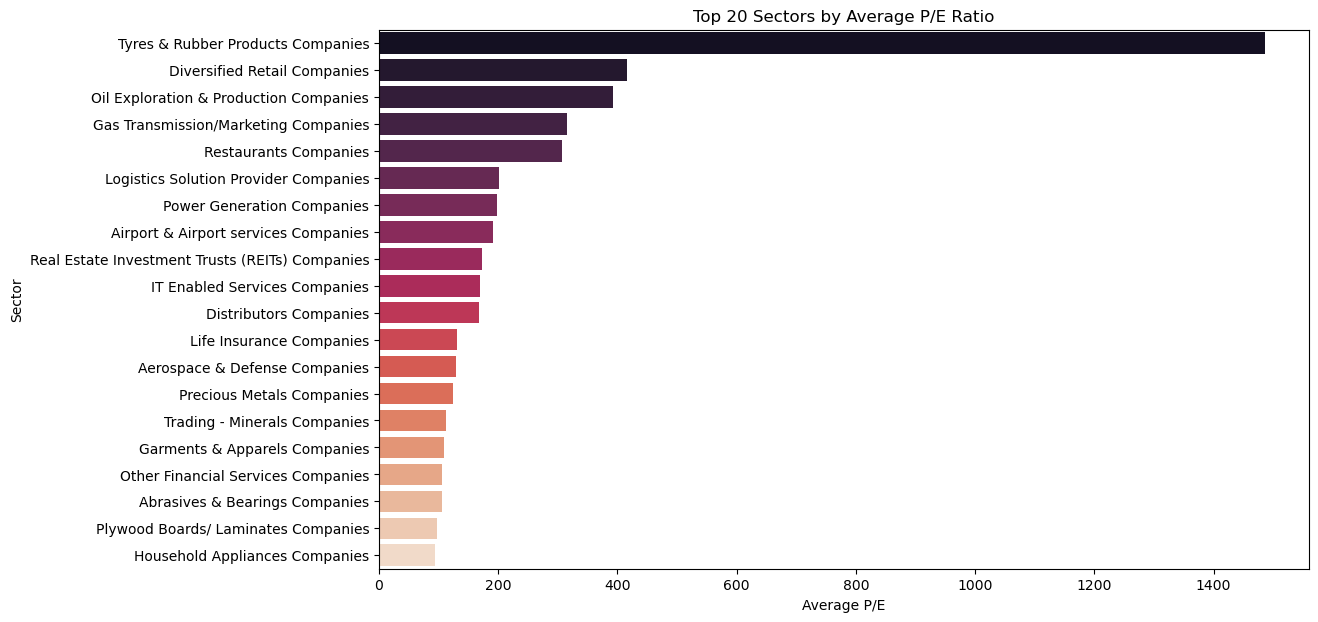

In [58]:
#7. Average P/E by Sector

sector_pe = (
    master_df.groupby("Sector")["P/E"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))
sns.barplot(
    x=sector_pe.values,
    y=sector_pe.index,
    palette="rocket"
)

plt.title("Top 20 Sectors by Average P/E Ratio")
plt.xlabel("Average P/E")
plt.ylabel("Sector")
plt.show()

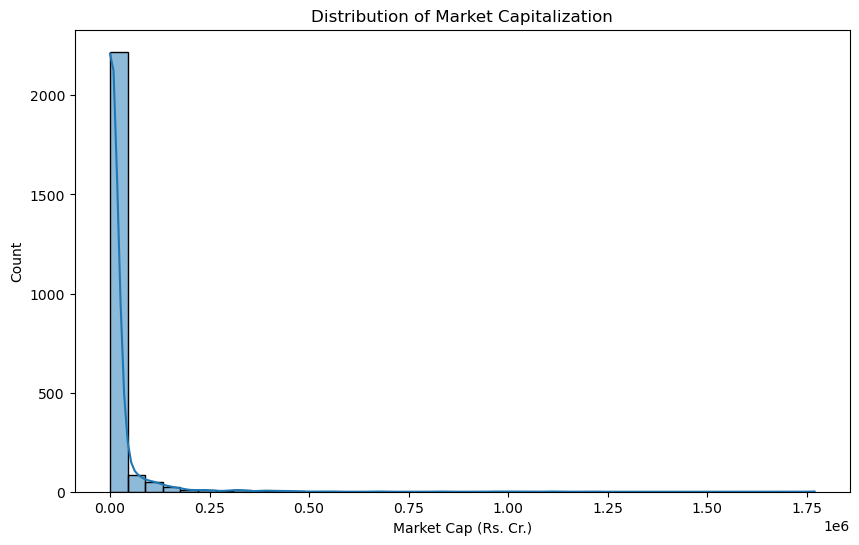

In [59]:
#8. Market Cap Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    master_df["Mar Cap Rs.Cr."],
    bins=40,
    kde=True
)

plt.title("Distribution of Market Capitalization")
plt.xlabel("Market Cap (Rs. Cr.)")
plt.show()

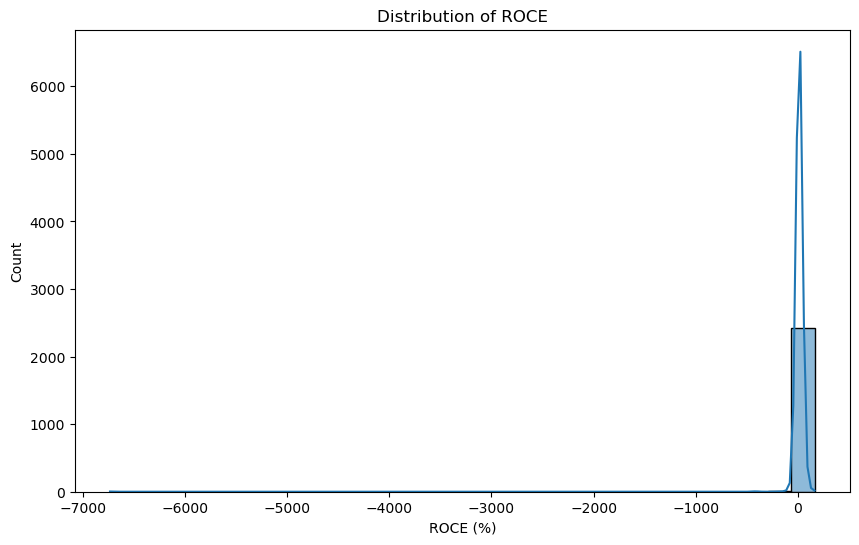

In [60]:
#9. ROCE Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    master_df["ROCE %"],
    bins=30,
    kde=True
)

plt.title("Distribution of ROCE")
plt.xlabel("ROCE (%)")
plt.show()

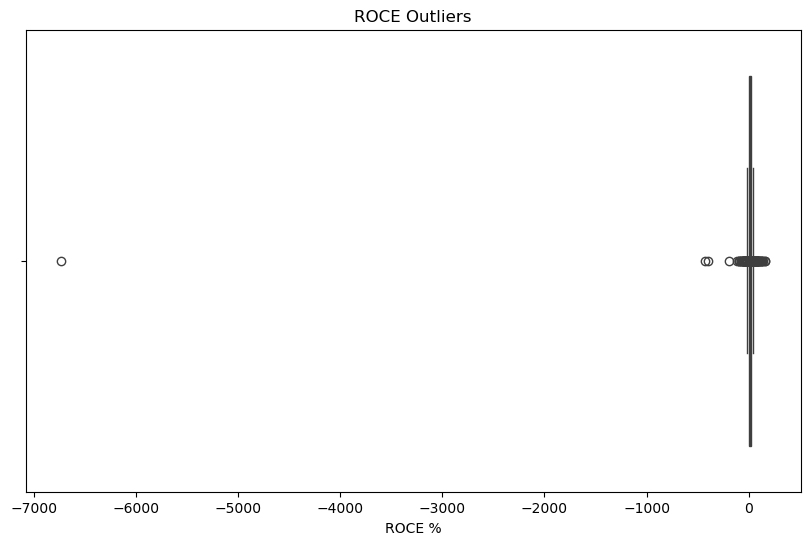

In [61]:
#10. Boxplot (Outlier Detection)

plt.figure(figsize=(10,6))

sns.boxplot(
    x=master_df["ROCE %"]
)

plt.title("ROCE Outliers")
plt.show()

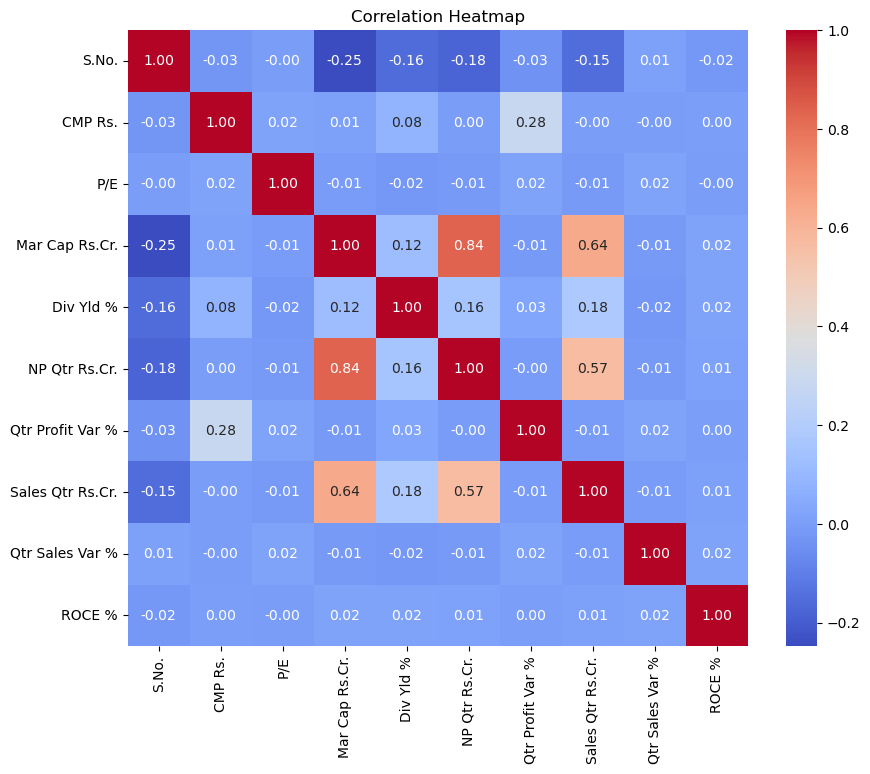

In [62]:
#11. Correlation Heatmap

plt.figure(figsize=(10,8))

numeric_df = master_df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

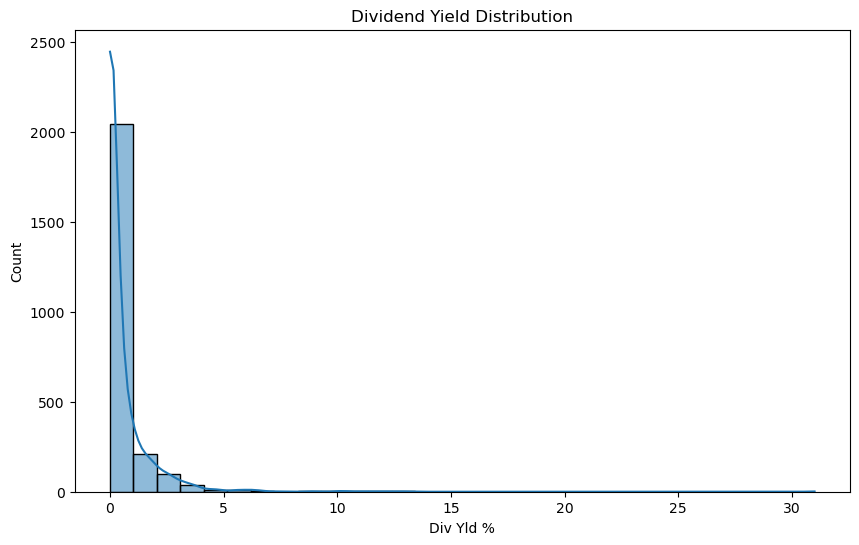

In [65]:
# 14. Dividend Yield Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    master_df["Div Yld %"],
    bins=30,
    kde=True
)

plt.title("Dividend Yield Distribution")
plt.show()

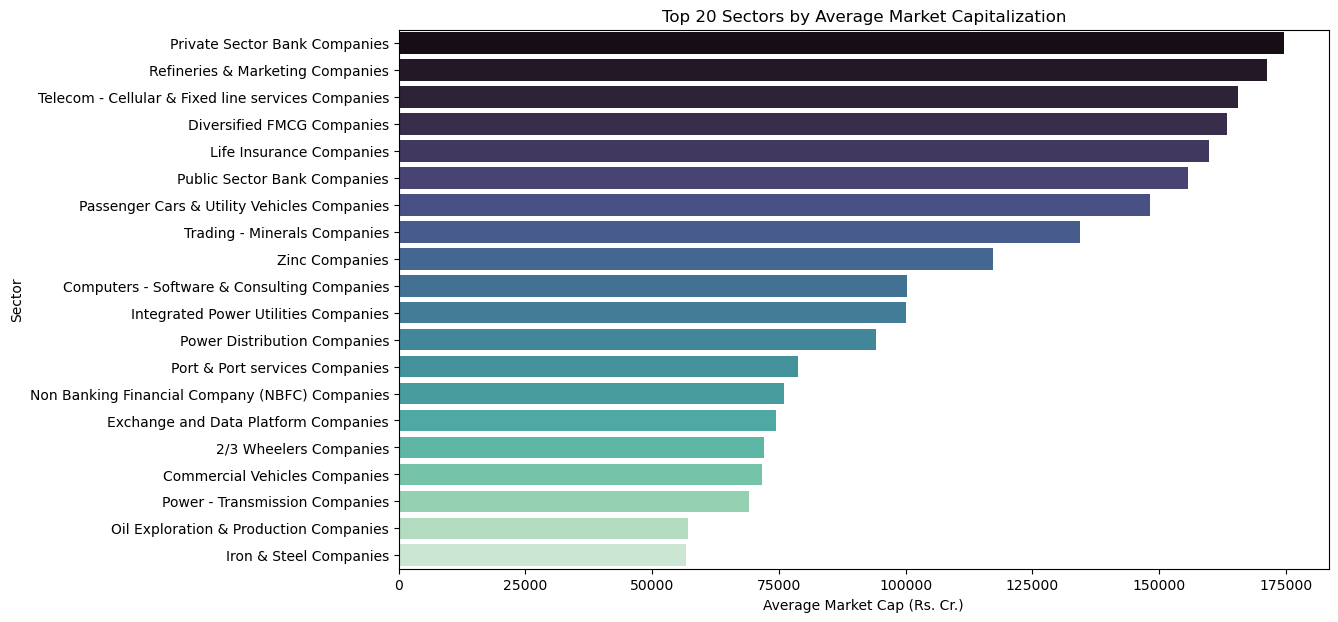

In [66]:
#15. Top 20 Sectors by Average Market Cap

sector_cap = (
    master_df.groupby("Sector")["Mar Cap Rs.Cr."]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,7))

sns.barplot(
    x=sector_cap.values,
    y=sector_cap.index,
    palette="mako"
)

plt.title("Top 20 Sectors by Average Market Capitalization")
plt.xlabel("Average Market Cap (Rs. Cr.)")
plt.ylabel("Sector")
plt.show()

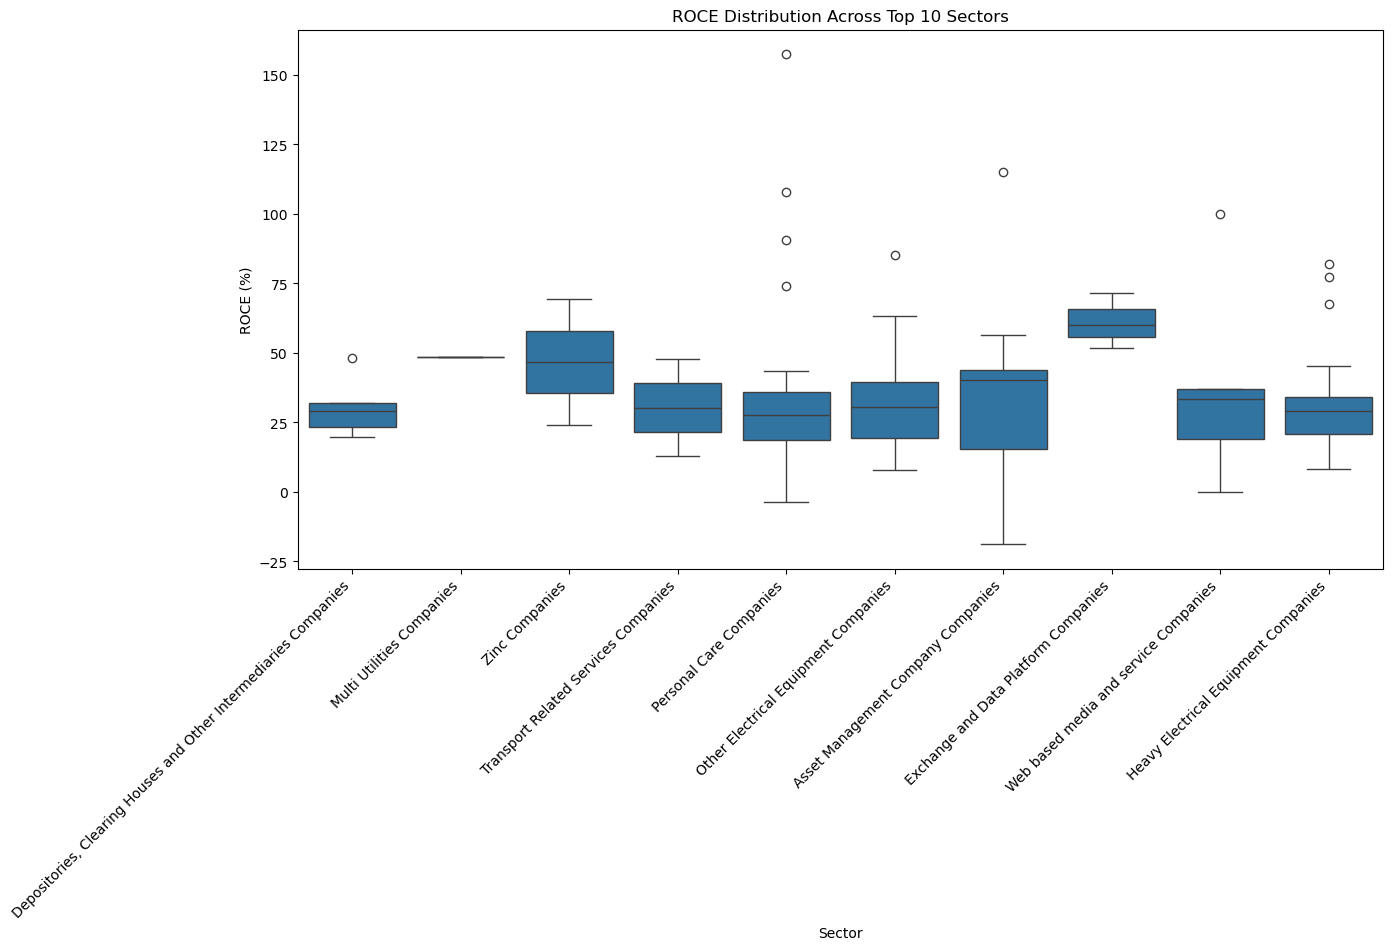

In [67]:
top_sectors = (
    master_df.groupby("Sector")["ROCE %"]
    .median()
    .nlargest(10)
    .index
)

plot_df = master_df[
    master_df["Sector"].isin(top_sectors)
]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=plot_df,
    x="Sector",
    y="ROCE %"
)

plt.xticks(rotation=45, ha="right")

plt.title("ROCE Distribution Across Top 10 Sectors")
plt.xlabel("Sector")
plt.ylabel("ROCE (%)")

plt.show()

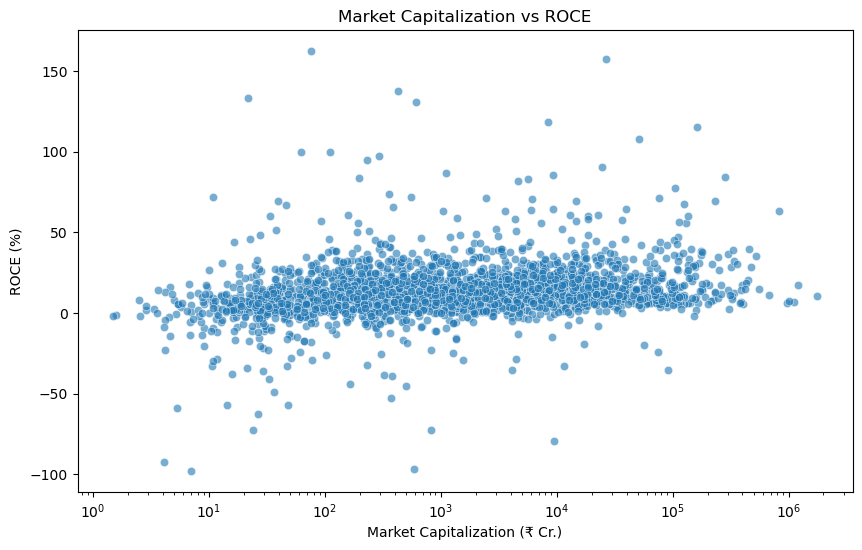

In [130]:
#Do larger companies use their capital more efficiently?
scatter_df = master_df[
    (master_df["ROCE %"] >= -100) &
    (master_df["ROCE %"] <= 200)
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_df,
    x="Mar Cap Rs.Cr.",
    y="ROCE %",
    alpha=0.6
)

plt.xscale("log")

plt.title("Market Capitalization vs ROCE")
plt.xlabel("Market Capitalization (₹ Cr.)")
plt.ylabel("ROCE (%)")

plt.show()

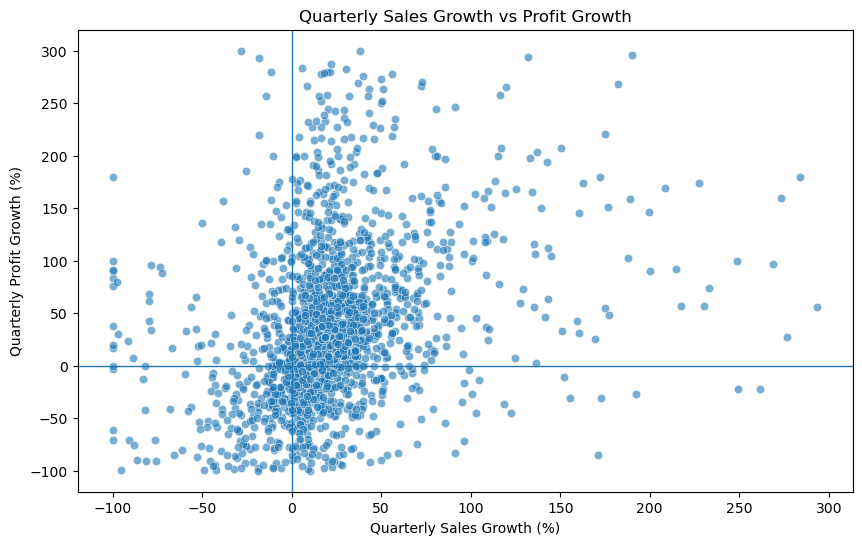

In [132]:
#Does increasing sales translate into increasing profit?
growth_df = master_df[
    (master_df["Qtr Sales Var %"].between(-100, 300)) &
    (master_df["Qtr Profit Var %"].between(-100, 300))
].copy()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=growth_df,
    x="Qtr Sales Var %",
    y="Qtr Profit Var %",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Quarterly Sales Growth vs Profit Growth")
plt.xlabel("Quarterly Sales Growth (%)")
plt.ylabel("Quarterly Profit Growth (%)")

plt.show()

# Inferential Statistics

Test 1 — Pearson Correlation Significance

In [165]:
#Is the relationship between Sales Growth and Profit Growth statistically significant?
from scipy.stats import pearsonr

test_df = master_df[
    ["Qtr Sales Var %", "Qtr Profit Var %"]
].dropna()

r, p_value = pearsonr(
    test_df["Qtr Sales Var %"],
    test_df["Qtr Profit Var %"]
)

print("Correlation:", r)
print("P-value:", p_value)

Correlation: 0.01716368052333813
P-value: 0.39771392367444597


## Test 2 — One-Way ANOVA

### Business Question:
Does the average ROCE differ significantly across sectors?

### H₀:
The mean ROCE is the same across the selected sectors.

### H₁:
At least one sector has a different mean ROCE.

In [169]:
from scipy.stats import f_oneway
top_sectors = (
    master_df["Sector"]
    .value_counts()
    .head(10)
    .index
)

print(top_sectors)

Index(['Residential, Commercial Projects Companies',
       'Packaged Foods Companies', 'Paper & Paper Products Companies',
       'Investment Company Companies',
       'Non Banking Financial Company (NBFC) Companies',
       'Consulting Services Companies', 'Speciality Retail Companies',
       'Education Companies', 'Logistics Solution Provider Companies',
       'Packaging Companies'],
      dtype='object', name='Sector')


In [167]:
groups = []

for sector in top_sectors:

    roce_values = master_df.loc[
        master_df["Sector"] == sector,
        "ROCE %"
    ].dropna()

    groups.append(roce_values)

In [171]:
for sector, group in zip(top_sectors, groups):
    print(sector, ":", len(group), "companies")
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

Residential, Commercial Projects Companies : 25 companies
Packaged Foods Companies : 25 companies
Paper & Paper Products Companies : 25 companies
Investment Company Companies : 25 companies
Non Banking Financial Company (NBFC) Companies : 25 companies
Consulting Services Companies : 25 companies
Speciality Retail Companies : 25 companies
Education Companies : 25 companies
Logistics Solution Provider Companies : 25 companies
Packaging Companies : 25 companies
F-statistic: 2.6185784800510916
P-value: 0.0066501022681284775


In [173]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant difference in mean ROCE across the selected sectors.")
else:
    print("Fail to reject H0")
    print("There is insufficient evidence to conclude that mean ROCE differs across the selected sectors.")

Reject H0
There is a statistically significant difference in mean ROCE across the selected sectors.
